# Coverage Test — 100 Single-Run Posteriors (100 galaxies each)

Test posterior calibration using 100 independent MCLMC runs. Each run estimates shear from 100 galaxies. The true shear is $\gamma = (-0.05, 0.05)$.

In [1]:
import sys
sys.path.append("..")

import glob
import numpy as np
import matplotlib.pyplot as plt

from src.shearest.posterior_utils import (
    load_gmm,
    compute_coverage,
    coverage_table,
    combine_gmms,
    combine_gmms_gaussian,
    plot_coverage,
    plot_gmm_contours,
)

## 1. Load posteriors

In [2]:
N_COV = 100  # Number of coverage tests
base_dir = "../outputs/coverage_test/cov_"

true_g = np.array([-0.05, 0.05])
prior_sigma = 0.1

cov_posteriors = []
for i in range(N_COV):
    gmm_files = sorted(glob.glob(f"{base_dir}{i}/mclmc_spergel_*/radio_shear_gmm.npz"))
    # print(f"Found {len(gmm_files)} GMM files")
    posteriors = [load_gmm(f) for f in gmm_files]
    cov_posteriors.append(combine_gmms_gaussian(posteriors, prior_mean=(0,0), prior_cov=np.eye(2)*prior_sigma**2))

In [ ]:
posteriors = cov_posteriors

## 2. Visualise a few posteriors

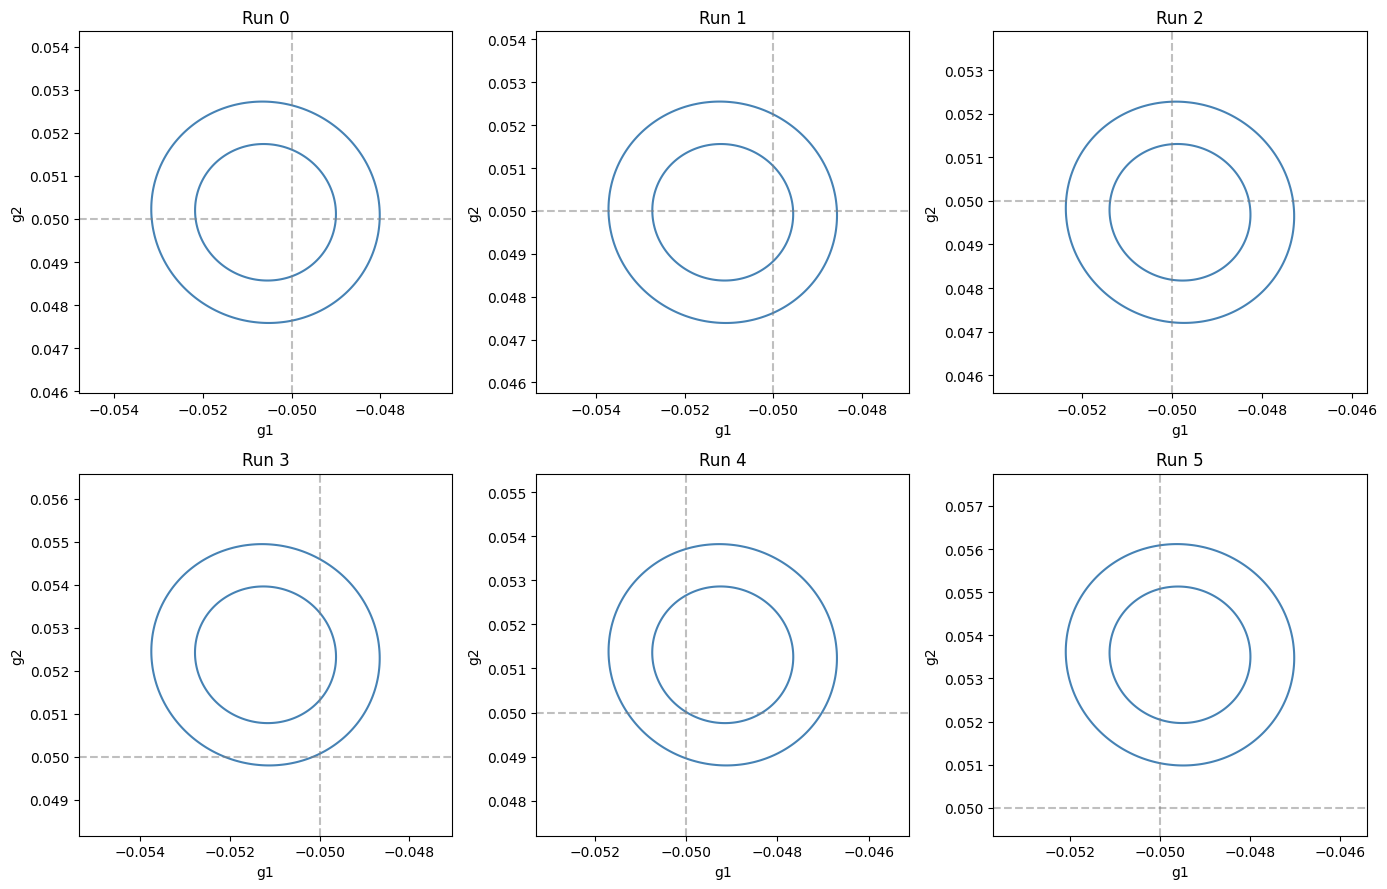

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, ax in enumerate(axes.flat):
    plot_gmm_contours(posteriors[i], ax=ax, true_g=true_g, color="steelblue")
    ax.set_title(f"Run {i}")
fig.tight_layout()
plt.show()

## 3. Compute credible levels

In [5]:
credible_levels = compute_coverage(posteriors, true_g)
print(f"Computed credible levels for {len(credible_levels)} posteriors")
print(f"Min: {credible_levels.min():.3f}, Max: {credible_levels.max():.3f}, Median: {np.median(credible_levels):.3f}")

Computed credible levels for 100 posteriors
Min: 0.029, Max: 0.997, Median: 0.472


## 4. Coverage table

In [6]:
table = coverage_table(credible_levels)

print(f"{'Nominal':>10} {'Empirical':>10} {'SE':>8} {'Status':>10}")
for nom, emp, se in zip(table["nominal"], table["empirical"], table["se"]):
    status = "OK" if abs(emp - nom) < 2 * se else "CHECK"
    print(f"{nom:>10.2f} {emp:>10.3f} {se:>8.3f} {status:>10}")

   Nominal  Empirical       SE     Status
      0.50      0.560    0.050         OK
      0.68      0.720    0.045         OK
      0.80      0.780    0.041         OK
      0.90      0.850    0.036         OK
      0.95      0.920    0.027         OK
      0.99      0.990    0.010         OK


## 5. Coverage plot

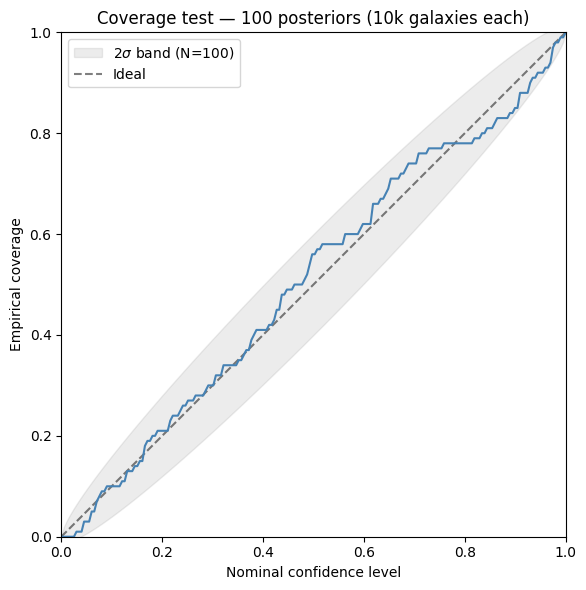

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_coverage(credible_levels, ax=ax)
ax.set_title(f"Coverage test — {len(credible_levels)} posteriors (10k galaxies each)")
fig.tight_layout()
# plt.savefig("coverage_test.pdf")
plt.show()

## 6. Credible level histogram

For a well-calibrated posterior, the credible levels should be uniformly distributed.

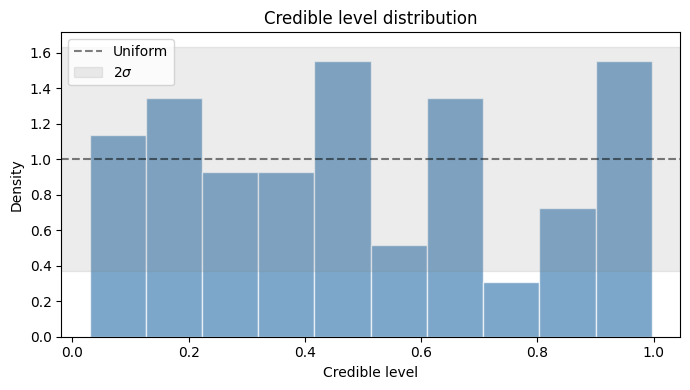

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
N = len(credible_levels)
n_bins = 10
ax.hist(credible_levels, bins=n_bins, density=True, alpha=0.7, color="steelblue", edgecolor="white")
ax.axhline(1.0, color="k", ls="--", alpha=0.5, label="Uniform")
bin_se = 2 * np.sqrt(1.0 / (N * (1.0 / n_bins)))
ax.axhspan(1 - bin_se, 1 + bin_se, alpha=0.15, color="gray", label=r"$2\sigma$")
ax.set_xlabel("Credible level")
ax.set_ylabel("Density")
ax.set_title("Credible level distribution")
ax.legend()
fig.tight_layout()
plt.show()